# Forest-Fire Susceptibility — PyTorch MLP

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


warnings.filterwarnings("ignore")

RANDOM_STATE = 42                          # same seed as the reference notebook
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device(
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print(f"torch {torch.__version__}  |  device = {DEVICE}")

torch 2.12.1  |  device = mps


In [2]:
import os
from pathlib import Path


ROOT = Path(os.getcwd()).parent

FILE_PATH = ROOT / "data" / "processed" / "forest_fire_dataset_100m.parquet"

df_all = pd.read_parquet(FILE_PATH)
print(f"Full grid rows : {len(df_all):,}")

df = df_all[df_all["is_flammable"] == 1].reset_index(drop=True)
del df_all                                  # free ~350 MB

n_fire = int(df["fire_occurred"].sum())
print(f"Flammable rows : {len(df):,}")
print(f"Fire cells     : {n_fire:,}  ({df['fire_occurred'].mean():.3%})")
df.head(3)

Full grid rows : 2,652,763
Flammable rows : 2,123,648
Fire cells     : 4,131  (0.195%)


,lat,lon,lulc_code,is_flammable,elevation_m,slope_deg,aspect_deg,tri,twi,solar_radiation,...,fire_occurred,fire_count,log_dist_to_road,log_dist_to_settlement,log_dist_to_water,log_dist_to_cropland,log_dist_to_forest_edge,log_population_density,aspect_sin,aspect_cos
0,28.338750,85.206250,30.0,1.0,3996.016357,8.298960,115.434685,44.651226,1.918237,1.051519,...,0.0,0.0,7.772834,9.473521,5.656823,9.348288,6.737020,0.0,0.903076,-0.429482
1,28.338750,85.207083,30.0,1.0,3988.757324,5.597795,134.564407,22.365662,2.312514,1.063679,...,0.0,0.0,7.745241,9.476810,5.321737,9.342339,6.827996,0.0,0.712462,-0.701711
2,28.337917,85.207083,30.0,1.0,3982.971191,5.040665,111.113174,25.287224,2.416831,1.027782,...,0.0,0.0,7.720325,9.470748,5.399824,9.346911,6.852640,0.0,0.932871,-0.360211


##  Features and target


In [3]:
TOPO = [
    "elevation_m", 
    "slope_deg",
    "aspect_sin",
    "aspect_cos",
    "tri",
    "twi",
    "solar_radiation"
    ]

CLIMATE = [
    "temp_max_mean_c",
    "wind_max_mean_kmh",
    "precip_fire_season_mm",
    "drought_factor",
    "fwi_proxy", 
    "consec_dry_days_max"
    ]

VEG = [
    "ndvi_fire_season",
    "ndvi_premonsoon",
    "ndvi_anomaly",
    "evi",
    "nbr",
    "ndwi",
    "lst_fire_season_mean_c"
    ]

HUMAN = [
    "log_dist_to_road", 
    "log_dist_to_settlement",
    "log_dist_to_forest_edge",
    "log_dist_to_cropland",
    "log_population_density"
    ]

LAND    = ["lulc_code"]

FEATURES = TOPO + CLIMATE + VEG + HUMAN + LAND   # 26 columns

TARGET   = "fire_occurred"

missing = [c for c in FEATURES + [TARGET, "lat", "lon"] if c not in df.columns]

assert not missing, f"Missing columns in parquet: {missing}"

print(f"{len(FEATURES)} features OK; target = '{TARGET}'")

26 features OK; target = 'fire_occurred'


## Spatial block split (train / validation / test)

In [4]:
BLOCK_DEG = 0.1                              # ~11 km tiles at this latitude
df["block_id"] = (np.floor(df["lat"] / BLOCK_DEG).astype(int).astype(str) + "_" +
                  np.floor(df["lon"] / BLOCK_DEG).astype(int).astype(str))

blocks   = df["block_id"].unique()
rng      = np.random.RandomState(RANDOM_STATE)
shuffled = rng.permutation(blocks)

n_test = int(0.20 * len(shuffled))
n_val  = int(0.15 * len(shuffled))          # carved from the non-test remainder
test_blocks  = set(shuffled[:n_test])
val_blocks   = set(shuffled[n_test:n_test + n_val])
# (train = everything else)

test_mask  = df["block_id"].isin(test_blocks).values
val_mask   = df["block_id"].isin(val_blocks).values
train_mask = ~(test_mask | val_mask)

X = df[FEATURES]
y = df[TARGET].astype(int).values

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# sanity: the three block sets must not overlap
assert not (test_blocks & val_blocks)
print(f"blocks total/train/val/test : {len(blocks)} / "
      f"{len(blocks) - len(val_blocks) - len(test_blocks)} / {len(val_blocks)} / {len(test_blocks)}")
print(f"train rows / fires : {len(X_train):,} / {int(y_train.sum()):,}")
print(f"val   rows / fires : {len(X_val):,} / {int(y_val.sum()):,}")
print(f"test  rows / fires : {len(X_test):,} / {int(y_test.sum()):,}")

blocks total/train/val/test : 230 / 150 / 34 / 46
train rows / fires : 1,335,054 / 2,561
val   rows / fires : 345,285 / 843
test  rows / fires : 443,309 / 727


## Impute and standardise 

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
    
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler  = StandardScaler().fit(imputer.transform(X_train))

def prep(frame):
    return scaler.transform(imputer.transform(frame)).astype("float32")

X_train_sc = prep(X_train)
X_val_sc   = prep(X_val)
X_test_sc  = prep(X_test)
print("scaled matrices:", X_train_sc.shape, X_val_sc.shape, X_test_sc.shape)

scaled matrices: (1335054, 26) (345285, 26) (443309, 26)


## Tensors and `DataLoader`s

in pytorch everything works on tensors, datasets and data loaders

In [6]:
BATCH_SIZE = 4096          # large batches so each one contains several of the rare fire pixels

def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_train_sc), to_tensor(y_train).unsqueeze(1))

# DataLoader is used to load the data in batches
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

Xval_t  = to_tensor(X_val_sc).to(DEVICE)
Xtest_t = to_tensor(X_test_sc).to(DEVICE)
print(f"train batches/epoch: {len(train_dl):,}")

train batches/epoch: 326


## 7 · The network

- we have 26 feature inputs
- use 128->64->1 networks

In [7]:
class FireMLP(nn.Module):
    def __init__(self, n_features, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128), # used to normalize the data
            nn.ReLU(),
            nn.Dropout(p_drop), # set 30 % of weights to 0

            nn.Linear(128, 64),
            nn.BatchNorm1d(64), # used to normalize the data
            nn.ReLU(),
            nn.Dropout(p_drop), # set 30 % of weights to 0

            nn.Linear(64, 1),               # one logit
        )

    def forward(self, x):
        return self.net(x)

model = FireMLP(n_features=len(FEATURES)).to(DEVICE)
print(model)
model.eval()
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

FireMLP(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
trainable params: 12161


In [8]:
from torchviz import make_dot
x = torch.randn(2, len(FEATURES), device=DEVICE)
y = model(x)
make_dot(
    y,
    params=dict(model.named_parameters()),
    show_attrs=True,
    show_saved=True,
).render(ROOT / "outputs" / "firemlp.png", format="png")

'/Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/firemlp.png.png'

## Weighted loss and optimiser


In [9]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())

raw_ratio = n_neg / n_pos

POS_WEIGHT_CAP = 50.0   

pw_value = min(POS_WEIGHT_CAP, raw_ratio)
pos_weight = torch.tensor([pw_value], dtype=torch.float32, device=DEVICE)
print(f"raw neg/pos ratio = {raw_ratio:,.1f}  ->  using pos_weight = {pw_value:.1f}")

# Binary cross entropy loss 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam optimizer for weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

raw neg/pos ratio = 520.3  ->  using pos_weight = 50.0


In [10]:

from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, classification_report, confusion_matrix,
)

@torch.no_grad()
def predict_proba(net, X_tensor):
    net.eval()
    return torch.sigmoid(net(X_tensor)).cpu().numpy().ravel()

MAX_EPOCHS = 30
PATIENCE   = 8

history   = {"train_loss": [], "val_ap": []}
best_ap   = -1.0
best_state = None
wait      = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(train_ds)

    val_ap = average_precision_score(y_val, predict_proba(model, Xval_t))
    history["train_loss"].append(train_loss)
    history["val_ap"].append(val_ap)

    flag = ""
    if val_ap > best_ap:
        best_ap, wait = val_ap, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = "  <- best"
    else:
        wait += 1
    print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_AUC-PR={val_ap:.4f}{flag}")

    if wait >= PATIENCE:
        print(f"early stop (no val improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)            # restore best checkpoint
print(f"\nbest val AUC-PR = {best_ap:.4f}")

epoch  1  train_loss=0.3386  val_AUC-PR=0.0148  <- best
epoch  2  train_loss=0.2926  val_AUC-PR=0.0137
epoch  3  train_loss=0.2903  val_AUC-PR=0.0153  <- best
epoch  4  train_loss=0.2891  val_AUC-PR=0.0149
epoch  5  train_loss=0.2876  val_AUC-PR=0.0141
epoch  6  train_loss=0.2851  val_AUC-PR=0.0135
epoch  7  train_loss=0.2839  val_AUC-PR=0.0138
epoch  8  train_loss=0.2829  val_AUC-PR=0.0145
epoch  9  train_loss=0.2819  val_AUC-PR=0.0144
epoch 10  train_loss=0.2818  val_AUC-PR=0.0139
epoch 11  train_loss=0.2816  val_AUC-PR=0.0135
early stop (no val improvement for 8 epochs)

best val AUC-PR = 0.0153


## 10 · Training curves

Training loss should fall steadily; validation AUC-PR should rise then plateau.
If val AUC-PR turned down while loss kept dropping, that would be overfitting —
exactly what early stopping guards against.

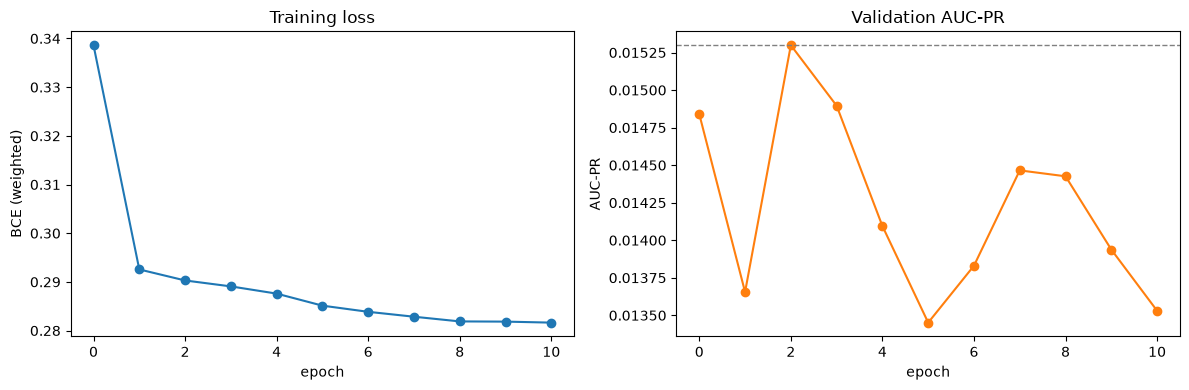

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["train_loss"], marker="o")
ax[0].set(title="Training loss", xlabel="epoch", ylabel="BCE (weighted)")
ax[1].plot(history["val_ap"], marker="o", color="C1")
ax[1].axhline(best_ap, ls="--", c="grey", lw=1)
ax[1].set(title="Validation AUC-PR", xlabel="epoch", ylabel="AUC-PR")

plt.tight_layout(); plt.show()

## 11 · Evaluate on the spatial hold-out

- **AUC-PR** — the headline metric for rare-event detection. 
- **AUC-ROC** — secondary; optimistic under heavy imbalance.
- **best-F1 threshold** — the cut on predicted probability that maximises F1.
  We report the classification report and confusion matrix at that threshold,
  *not* the naive 0.5.

In [12]:
def evaluate(name, y_true, y_prob, show_report=True):
    ap  = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_i   = int(np.nanargmax(f1s))
    best_thr = float(thr[min(best_i, len(thr) - 1)])
    best_f1  = float(f1s[best_i])
    print(f"{name}:  AUC-PR={ap:.3f}   AUC-ROC={roc:.3f}   best-F1={best_f1:.3f} @thr={best_thr:.3f}")
    if show_report:
        y_hat = (y_prob >= best_thr).astype(int)
        print(classification_report(y_true, y_hat, target_names=["Non-fire", "Fire"], digits=3))
        print("confusion matrix [rows=true, cols=pred]:\n", confusion_matrix(y_true, y_hat))
    return {"AUC_PR": ap, "AUC_ROC": roc, "best_F1": best_f1, "thr": best_thr, "y_prob": y_prob}

test_prob = predict_proba(model, Xtest_t)
no_skill  = y_test.mean()
print(f"no-skill baseline AUC-PR (= positive rate) = {no_skill:.4f}\n")
mlp_res = evaluate("PyTorch MLP", y_test, test_prob)

no-skill baseline AUC-PR (= positive rate) = 0.0016

PyTorch MLP:  AUC-PR=0.006   AUC-ROC=0.723   best-F1=0.034 @thr=0.426
              precision    recall  f1-score   support

    Non-fire      0.999     0.993     0.996    442582
        Fire      0.021     0.092     0.034       727

    accuracy                          0.991    443309
   macro avg      0.510     0.542     0.515    443309
weighted avg      0.997     0.991     0.994    443309

confusion matrix [rows=true, cols=pred]:
 [[439411   3171]
 [   660     67]]


## 12 · Precision–Recall and ROC curves

The dashed line on the PR plot is the no-skill baseline (the positive rate). The
gap between our curve and that line is the model's real lift.

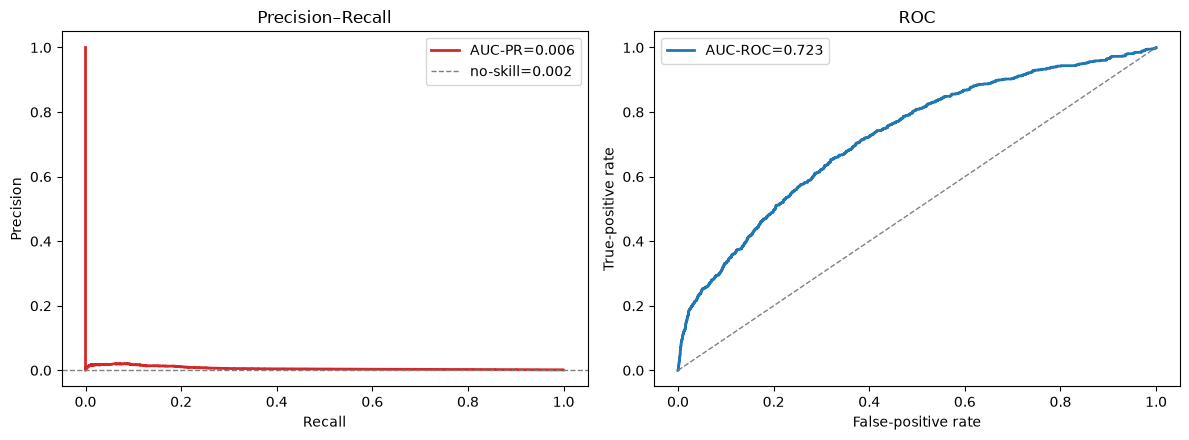

In [ ]:
prec, rec, _ = precision_recall_curve(y_test, test_prob)
fpr, tpr, _  = roc_curve(y_test, test_prob)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(rec, prec, color="C3", lw=2, label=f"AUC-PR={mlp_res['AUC_PR']:.3f}")
ax[0].axhline(no_skill, ls="--", c="grey", lw=1, label=f"no-skill={no_skill:.3f}")
ax[0].set(title="Precision–Recall", xlabel="Recall", ylabel="Precision"); ax[0].legend()

ax[1].plot(fpr, tpr, color="C0", lw=2, label=f"AUC-ROC={mlp_res['AUC_ROC']:.3f}")
ax[1].plot([0, 1], [0, 1], ls="--", c="grey", lw=1)
ax[1].set(title="ROC", xlabel="False-positive rate", ylabel="True-positive rate"); ax[1].legend()
plt.tight_layout()
plt.show()

## 13 · Save artifacts

For later inference we need three things together: the network **weights**, and
the fitted **imputer + scaler** (so new data is transformed exactly as in
training). We also stash the feature order and best threshold.

In [14]:
import joblib

OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), OUT / "pytorch_mlp_state.pt")
joblib.dump(
    {"imputer": imputer, 
     "scaler": scaler, 
     "features": FEATURES,
     "best_threshold": mlp_res["thr"],
     "test_AUC_PR": mlp_res["AUC_PR"]},
    OUT / "pytorch_mlp_preprocess.joblib",
)
print("saved:")
print(" ", OUT / "pytorch_mlp_state.pt")
print(" ", OUT / "pytorch_mlp_preprocess.joblib")

saved:
  /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/pytorch_mlp_state.pt
  /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/pytorch_mlp_preprocess.joblib
